# Transcript length analysis

This notebook analyzes transcript lengths in `lab/datasets/youtube_ai_dot_engineer/transcripts/`.

It computes per-transcript:
- character count
- word count
- bytes (UTF-8)

Then it plots distributions and surfaces the longest/shortest transcripts.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Find repo root by locating the transcripts directory."""
    target = Path("lab/datasets/youtube_ai_dot_engineer/transcripts")
    for p in (start, *start.parents):
        if (p / target).exists():
            return p
    raise FileNotFoundError(
        "Could not find repo root containing 'lab/datasets/youtube_ai_dot_engineer/transcripts'. "
        "Try running the notebook from the repo root."
    )


REPO_ROOT = find_repo_root(Path.cwd())

# Ensure lab's internal packages are importable (utils/, datasets/, trains/)
sys.path.insert(0, str(REPO_ROOT / "lab"))

TRANSCRIPTS_DIR = REPO_ROOT / "lab" / "datasets" / "youtube_ai_dot_engineer" / "transcripts"

files = sorted(TRANSCRIPTS_DIR.glob("*.txt"))
print(f"Transcripts dir: {TRANSCRIPTS_DIR}")
print(f"Found {len(files)} transcript files")
print("Example:", files[0].name if files else "<none>")


Transcripts dir: /Users/minkijung/Documents/SideProjects/innie/lab/datasets/youtube_ai_dot_engineer/transcripts
Found 100 transcript files
Example: -T6uZYYzkWw.txt


In [3]:
# Tokenizer (match `lab/trains/rlvr_youtube_reviews/train.py`)
#
# That training script gets the tokenizer from:
#   training_client = await tinker.ServiceClient().create_lora_training_client_async(base_model=..., rank=...)
#   tokenizer = training_client.get_tokenizer()
#
# We'll do the same here so token counts are comparable.

import asyncio
from typing import Any

import tinker


async def _get_training_tokenizer(*, base_model: str, lora_rank: int) -> Any:
    service_client = tinker.ServiceClient()
    training_client = await service_client.create_lora_training_client_async(
        base_model=base_model,
        rank=lora_rank,
    )
    return training_client.get_tokenizer()


BASE_MODEL = "meta-llama/Llama-3.1-8B"
LORA_RANK = 32

tokenizer = await _get_training_tokenizer(base_model=BASE_MODEL, lora_rank=LORA_RANK)
print("Tokenizer:", type(tokenizer).__name__, "for", BASE_MODEL)


/Users/minkijung/Documents/SideProjects/innie/lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Tokenizer: TokenizersBackend for meta-llama/Llama-3.1-8B


In [4]:
import re
from dataclasses import dataclass
from typing import Any

from utils.tokens import to_int_list


_HEADER_RE = re.compile(r"^Kind:\s*captions\s*Language:\s*[A-Za-z-]+\s*", re.IGNORECASE)


@dataclass(frozen=True)
class TranscriptStats:
    video_id: str
    path: Path
    bytes_utf8: int
    chars: int
    tokens: int


def read_text(path: Path) -> str:
    # Some files can be huge; read as text with replacement to avoid crashes.
    return path.read_text(encoding="utf-8", errors="replace")


def normalize_transcript_text(text: str) -> str:
    text = text.strip()
    text = _HEADER_RE.sub("", text)
    return text.strip()


def _encode_tokens(tokenizer: Any, text: str) -> list[int]:
    # Mirror the training script's behavior: use `.encode(...)` and normalize to list[int].
    try:
        return to_int_list(tokenizer.encode(text, add_special_tokens=False))
    except TypeError:
        # Some tokenizers don't accept `add_special_tokens`.
        return to_int_list(tokenizer.encode(text))


def compute_stats(path: Path, *, tokenizer: Any) -> TranscriptStats:
    raw = read_text(path)
    text = normalize_transcript_text(raw)
    bytes_utf8 = len(text.encode("utf-8", errors="replace"))
    chars = len(text)
    tokens = len(_encode_tokens(tokenizer, text))
    return TranscriptStats(
        video_id=path.stem,
        path=path,
        bytes_utf8=bytes_utf8,
        chars=chars,
        tokens=tokens,
    )


stats = [compute_stats(p, tokenizer=tokenizer) for p in files]

# Basic sanity checks
assert len(stats) == len(files)
print("Computed stats for", len(stats), "transcripts")
print("Sample:", stats[0])


Computed stats for 100 transcripts
Sample: TranscriptStats(video_id='-T6uZYYzkWw', path=PosixPath('/Users/minkijung/Documents/SideProjects/innie/lab/datasets/youtube_ai_dot_engineer/transcripts/-T6uZYYzkWw.txt'), bytes_utf8=34738, chars=34738, tokens=7171)


In [5]:
import math
import statistics


def pct(values: list[int], p: float) -> float:
    """Percentile with linear interpolation (p in [0, 100])."""
    if not values:
        return float("nan")
    xs = sorted(values)
    if len(xs) == 1:
        return float(xs[0])
    k = (len(xs) - 1) * (p / 100.0)
    f = math.floor(k)
    c = math.ceil(k)
    if f == c:
        return float(xs[int(k)])
    return xs[f] * (c - k) + xs[c] * (k - f)


token_counts = [s.tokens for s in stats]
char_counts = [s.chars for s in stats]
byte_counts = [s.bytes_utf8 for s in stats]

print("### Token count summary")
print("count:", len(token_counts))
print("min:", min(token_counts), "max:", max(token_counts))
print("mean:", round(statistics.mean(token_counts), 2))
print("median:", statistics.median(token_counts))
print("p10/p90:", round(pct(token_counts, 10), 2), "/", round(pct(token_counts, 90), 2))

print("\n### Character count summary")
print("min:", min(char_counts), "max:", max(char_counts))
print("mean:", round(statistics.mean(char_counts), 2))
print("median:", statistics.median(char_counts))
print("p10/p90:", round(pct(char_counts, 10), 2), "/", round(pct(char_counts, 90), 2))

# Longest / shortest
print("\n### Longest transcripts (by tokens)")
for s in sorted(stats, key=lambda x: x.tokens, reverse=True)[:10]:
    print(f"{s.video_id}\ttokens={s.tokens:,}\tchars={s.chars:,}\tbytes={s.bytes_utf8:,}")

print("\n### Shortest transcripts (by tokens)")
for s in sorted(stats, key=lambda x: x.tokens)[:10]:
    print(f"{s.video_id}\ttokens={s.tokens:,}\tchars={s.chars:,}\tbytes={s.bytes_utf8:,}")


### Token count summary
count: 100
min: 1657 max: 72238
mean: 17046.39
median: 11986.5
p10/p90: 7138.4 / 41540.8

### Character count summary
min: 6039 max: 313077
mean: 78000
median: 56070.5
p10/p90: 34549.6 / 185283.2

### Longest transcripts (by tokens)
TqC1qOfiVcQ	tokens=72,238	chars=313,077	bytes=313,083
2HNSG990Ew8	tokens=59,271	chars=260,329	bytes=260,329
k1t2xyWMUdY	tokens=49,578	chars=229,837	bytes=229,837
k8cnVCMYmNc	tokens=48,324	chars=211,488	bytes=211,488
xz0-brt56L8	tokens=47,920	chars=210,120	bytes=210,120
-cKUW6n8hBU	tokens=44,738	chars=202,699	bytes=202,699
hwCmfThIiS4	tokens=43,633	chars=197,565	bytes=197,565
VSdV-AdSlis	tokens=42,858	chars=185,294	bytes=185,294
HY_JyxAZsiE	tokens=41,719	chars=185,654	bytes=185,654
RFKCzGlAU6Q	tokens=41,674	chars=185,282	bytes=185,282

### Shortest transcripts (by tokens)
RQ5Jt8zDBp8	tokens=1,657	chars=7,001	bytes=7,001
xAfp-znTRx8	tokens=2,094	chars=6,039	bytes=6,039
mdEh4lBO_R0	tokens=2,384	chars=10,236	bytes=10,236
MC55hdWLq4o	toke

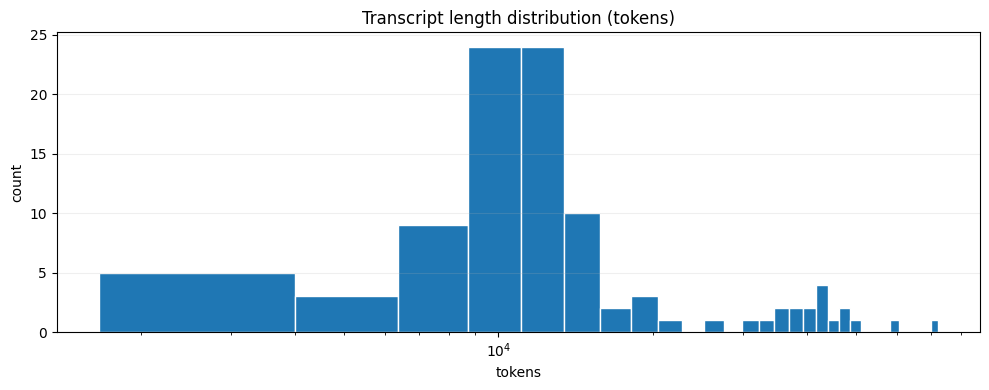

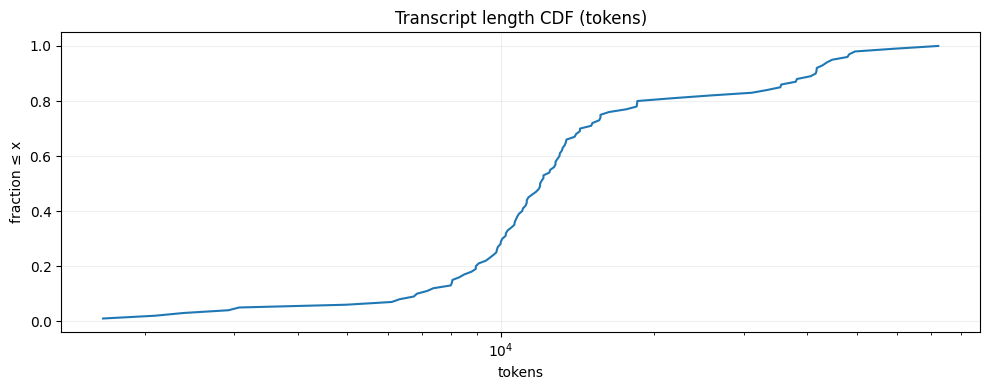

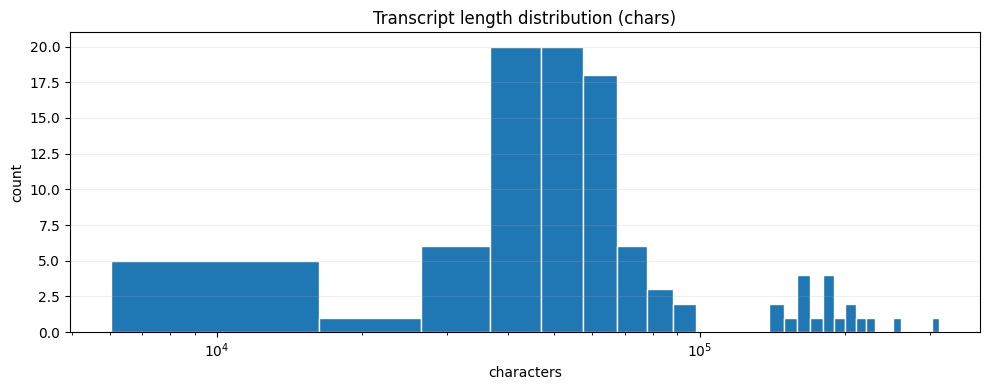

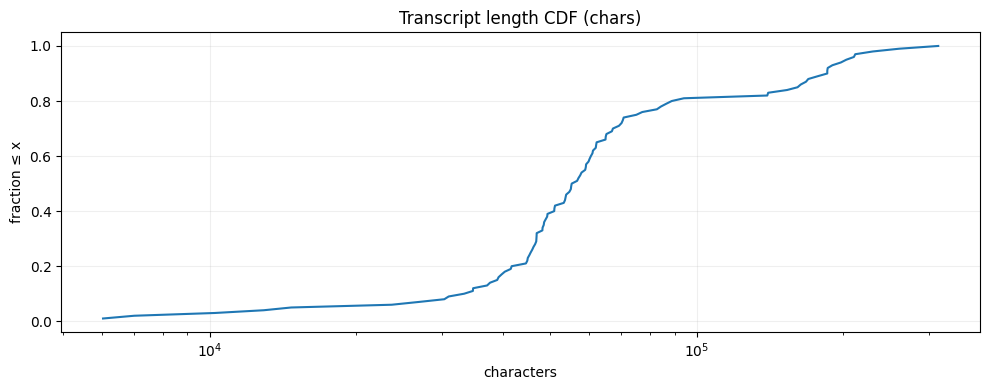

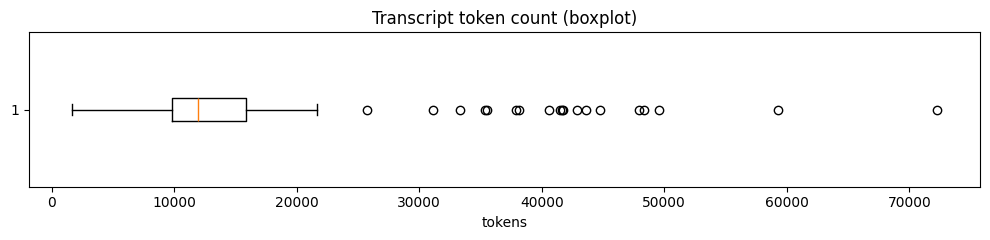

In [6]:
# Plots
#
# If matplotlib isn't installed in your environment, install it in the lab env:
#   uv add matplotlib

try:
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError(
        "matplotlib is required for plotting. Install it in the lab environment with: uv add matplotlib"
    ) from e


def plot_hist(values: list[int], title: str, xlabel: str, bins: int = 30, log_x: bool = False):
    plt.figure(figsize=(10, 4))
    plt.hist(values, bins=bins, edgecolor="white")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    if log_x:
        plt.xscale("log")
    plt.grid(True, axis="y", alpha=0.2)
    plt.tight_layout()


def plot_cdf(values: list[int], title: str, xlabel: str, log_x: bool = False):
    xs = sorted(values)
    ys = [(i + 1) / len(xs) for i in range(len(xs))]

    plt.figure(figsize=(10, 4))
    plt.plot(xs, ys)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("fraction ≤ x")
    if log_x:
        plt.xscale("log")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()


plot_hist(token_counts, "Transcript length distribution (tokens)", "tokens", bins=30, log_x=True)
plot_cdf(token_counts, "Transcript length CDF (tokens)", "tokens", log_x=True)

plot_hist(char_counts, "Transcript length distribution (chars)", "characters", bins=30, log_x=True)
plot_cdf(char_counts, "Transcript length CDF (chars)", "characters", log_x=True)

plt.figure(figsize=(10, 2.5))
plt.boxplot(token_counts, vert=False)
plt.title("Transcript token count (boxplot)")
plt.xlabel("tokens")
plt.tight_layout()

plt.show()


Embeddings dir: /Users/minkijung/Documents/SideProjects/innie/lab/datasets/youtube_ai_dot_engineer/embeddings
Found 300 feedback files
Example: lab/datasets/youtube_ai_dot_engineer/embeddings/executive_ai_strategy/-T6uZYYzkWw/feedback.txt

### Feedback token count summary
count: 300
min: 187 max: 602
mean: 338.42
median: 327.0
p10/p90: 272.6 / 415.1

### Feedback character count summary
min: 1013 max: 3340
mean: 1824.82
median: 1755.0
p10/p90: 1399.6 / 2302.1

### Longest feedbacks (by tokens)
principal_engineer_inference/a4BV0gGmXgA	tokens=602	chars=3,261	bytes=3,287	lab/datasets/youtube_ai_dot_engineer/embeddings/principal_engineer_inference/a4BV0gGmXgA/feedback.txt
principal_engineer_inference/fL1iJHtl51Q	tokens=569	chars=3,340	bytes=3,344	lab/datasets/youtube_ai_dot_engineer/embeddings/principal_engineer_inference/fL1iJHtl51Q/feedback.txt
principal_engineer_inference/rcsliSIy_YU	tokens=535	chars=2,893	bytes=2,903	lab/datasets/youtube_ai_dot_engineer/embeddings/principal_engineer_in

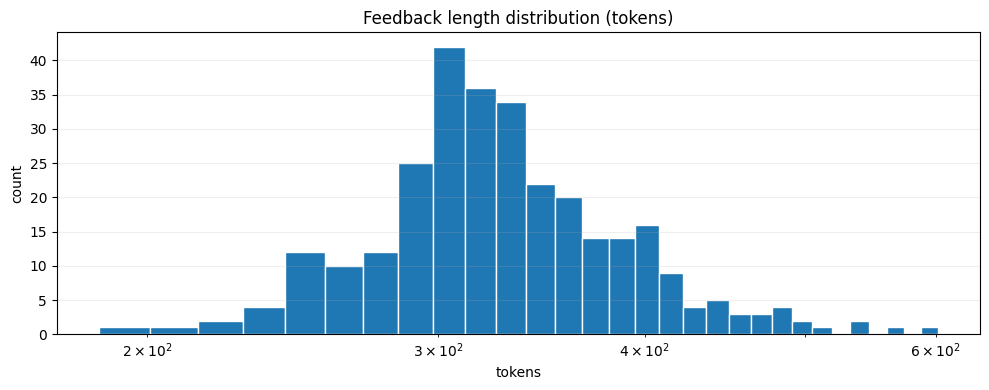

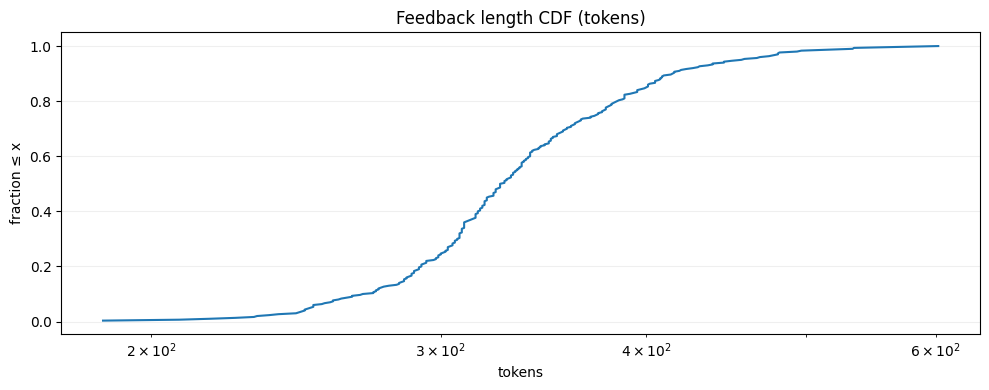

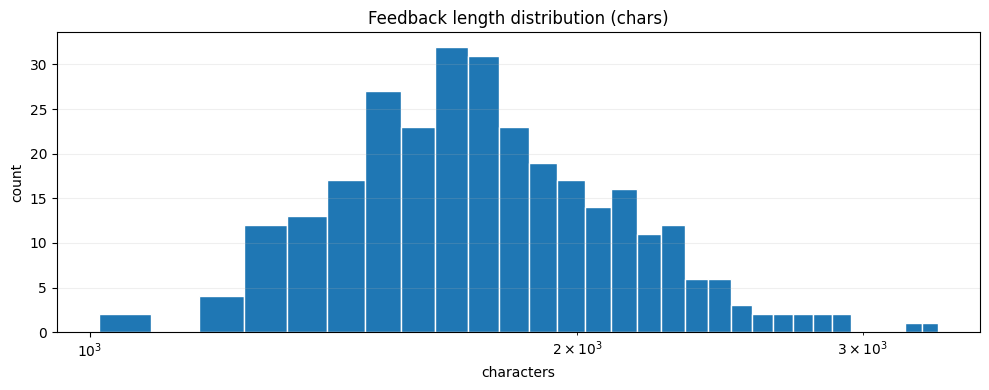

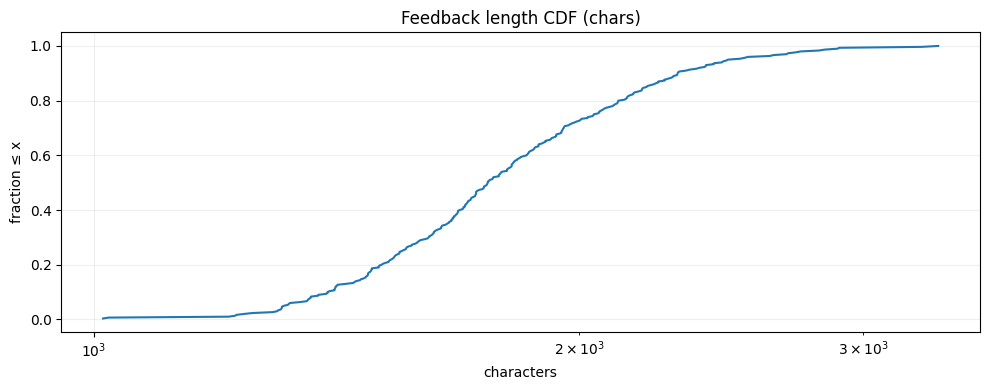

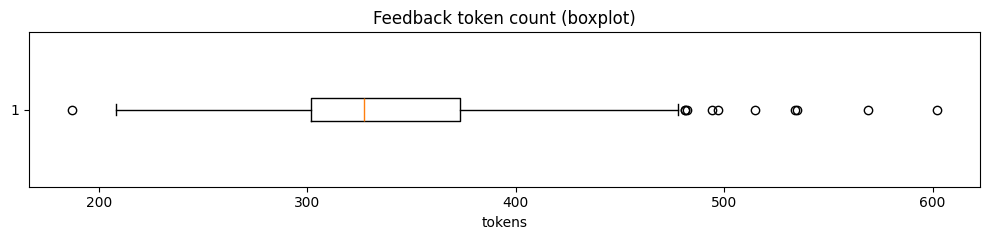

In [7]:
# Feedback length analysis (from embeddings)
#
# This scans:
#   lab/datasets/youtube_ai_dot_engineer/embeddings/**/feedback.txt
#
# and plots token/char/byte distributions using the same tokenizer + helpers above.

import statistics
from dataclasses import dataclass
from typing import Any


EMBEDDINGS_DIR = REPO_ROOT / "lab" / "datasets" / "youtube_ai_dot_engineer" / "embeddings"
feedback_files = sorted(EMBEDDINGS_DIR.rglob("feedback.txt"))

print(f"Embeddings dir: {EMBEDDINGS_DIR}")
print(f"Found {len(feedback_files)} feedback files")
print("Example:", str(feedback_files[0].relative_to(REPO_ROOT)) if feedback_files else "<none>")


@dataclass(frozen=True)
class FeedbackStats:
    collection: str
    video_id: str
    path: Path
    bytes_utf8: int
    chars: int
    tokens: int


def normalize_feedback_text(text: str) -> str:
    return text.strip()


def compute_feedback_stats(path: Path, *, tokenizer: Any) -> FeedbackStats:
    raw = read_text(path)
    text = normalize_feedback_text(raw)

    bytes_utf8 = len(text.encode("utf-8", errors="replace"))
    chars = len(text)
    tokens = len(_encode_tokens(tokenizer, text))

    # embeddings/<collection>/<video_id>/feedback.txt
    video_id = path.parent.name
    collection = path.parent.parent.name if path.parent.parent is not None else "<unknown>"

    return FeedbackStats(
        collection=collection,
        video_id=video_id,
        path=path,
        bytes_utf8=bytes_utf8,
        chars=chars,
        tokens=tokens,
    )


feedback_stats = [compute_feedback_stats(p, tokenizer=tokenizer) for p in feedback_files]

if not feedback_stats:
    raise FileNotFoundError(f"No feedback.txt files found under: {EMBEDDINGS_DIR}")

feedback_token_counts = [s.tokens for s in feedback_stats]
feedback_char_counts = [s.chars for s in feedback_stats]
feedback_byte_counts = [s.bytes_utf8 for s in feedback_stats]

print("\n### Feedback token count summary")
print("count:", len(feedback_token_counts))
print("min:", min(feedback_token_counts), "max:", max(feedback_token_counts))
print("mean:", round(statistics.mean(feedback_token_counts), 2))
print("median:", statistics.median(feedback_token_counts))
print(
    "p10/p90:",
    round(pct(feedback_token_counts, 10), 2),
    "/",
    round(pct(feedback_token_counts, 90), 2),
)

print("\n### Feedback character count summary")
print("min:", min(feedback_char_counts), "max:", max(feedback_char_counts))
print("mean:", round(statistics.mean(feedback_char_counts), 2))
print("median:", statistics.median(feedback_char_counts))
print("p10/p90:", round(pct(feedback_char_counts, 10), 2), "/", round(pct(feedback_char_counts, 90), 2))

print("\n### Longest feedbacks (by tokens)")
for s in sorted(feedback_stats, key=lambda x: x.tokens, reverse=True)[:10]:
    rel = str(s.path.relative_to(REPO_ROOT))
    print(f"{s.collection}/{s.video_id}\ttokens={s.tokens:,}\tchars={s.chars:,}\tbytes={s.bytes_utf8:,}\t{rel}")

print("\n### Shortest feedbacks (by tokens)")
for s in sorted(feedback_stats, key=lambda x: x.tokens)[:10]:
    rel = str(s.path.relative_to(REPO_ROOT))
    print(f"{s.collection}/{s.video_id}\ttokens={s.tokens:,}\tchars={s.chars:,}\tbytes={s.bytes_utf8:,}\t{rel}")

plot_hist(
    feedback_token_counts,
    "Feedback length distribution (tokens)",
    "tokens",
    bins=30,
    log_x=True,
)
plot_cdf(
    feedback_token_counts,
    "Feedback length CDF (tokens)",
    "tokens",
    log_x=True,
)

plot_hist(
    feedback_char_counts,
    "Feedback length distribution (chars)",
    "characters",
    bins=30,
    log_x=True,
)
plot_cdf(
    feedback_char_counts,
    "Feedback length CDF (chars)",
    "characters",
    log_x=True,
)

plt.figure(figsize=(10, 2.5))
plt.boxplot(feedback_token_counts, vert=False)
plt.title("Feedback token count (boxplot)")
plt.xlabel("tokens")
plt.tight_layout()

plt.show()